# Interior Point Method for Linear Programming

## Linear programming

A linear program minimizes $c^\top x$ under affine inequalities
$$
A x \le b.
$$
Interior-point methods solve a sequence of smooth barrier problems
$$
\phi_\mu(x)=c^\top x-\mu\sum_i \log\bigl(b_i-a_i^\top x\bigr),
$$
and track the central path as $\mu\downarrow 0$.


### Environment setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from ipywidgets import interact, FloatSlider, IntSlider

### 2D feasible polytope

We work in 2D to visualize the central path. We define a random convex polygon via half-space constraints $Ax \leq b$. Each row $a_i$ of $A$ defines an inward normal, and $b_i$ the offset.

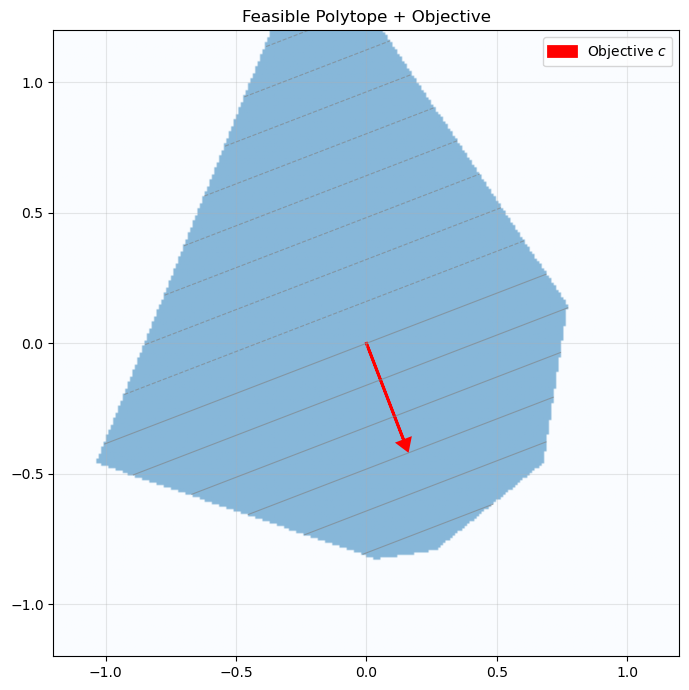

In [2]:
rng = np.random.default_rng(42)

# Generate a random convex polygon as intersection of half-spaces
# Sample normals uniformly on the unit circle
n_sides = 8
angles = np.sort(rng.uniform(0, 2*np.pi, n_sides))
A = np.column_stack([np.cos(angles), np.sin(angles)])
# Offsets: all half-spaces pass through the unit circle
b = np.ones(n_sides) * 0.7 + 0.2 * rng.random(n_sides)

# Display the feasible region
def is_feasible(pts, A, b):
    return np.all(pts @ A.T <= b[None, :], axis=1)

g = 260
t_grid = np.linspace(-1.2, 1.2, g)
Yg, Xg = np.meshgrid(t_grid, t_grid)
pts_grid = np.column_stack([Xg.ravel(), Yg.ravel()])
feasible_mask = is_feasible(pts_grid, A, b).reshape(g, g)

# Objective direction
c_obj = rng.standard_normal(2)
c_obj = c_obj / np.linalg.norm(c_obj)
f_obj = (pts_grid @ c_obj).reshape(g, g)

fig, ax = plt.subplots(figsize=(7, 7))
ax.imshow(feasible_mask.T.astype(float), extent=[-1.2,1.2,-1.2,1.2],
          origin='lower', cmap='Blues', alpha=0.6, vmin=0, vmax=1.5)
# Show objective level sets inside feasible region
f_masked = np.where(feasible_mask, f_obj, np.nan)
ax.contour(Xg, Yg, f_masked, levels=15, colors='gray', linewidths=0.8, alpha=0.6)
# Draw objective vector
ax.arrow(0, 0, 0.4*c_obj[0], 0.4*c_obj[1], head_width=0.05, head_length=0.04,
         fc='red', ec='red', lw=2, label='Objective $c$')
ax.set_xlim(-1.2, 1.2); ax.set_ylim(-1.2, 1.2)
ax.set_aspect('equal')
ax.set_title('Feasible Polytope + Objective', fontsize=12)
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig('lp_feasible.png', dpi=100, bbox_inches='tight'); plt.show()

### Log-barrier method

We minimize the barrier-penalized objective:
$$\phi_\mu(x) = c^T x - \mu \sum_i \log(b_i - a_i^T x)$$

for a decreasing sequence of $\mu$ values, warm-starting each solve from the previous solution. The path traced by the solutions is the **central path**.

In [3]:
def log_barrier_obj(x, c, A, b, mu):
    slacks = b - A @ x
    if np.any(slacks <= 0):
        return np.inf
    return c @ x - mu * np.sum(np.log(slacks))

def log_barrier_grad(x, c, A, b, mu):
    slacks = b - A @ x
    return c + mu * (A.T @ (1.0 / slacks))

# Find analytic center (mu=1 minimizer)
x0 = np.zeros(2)  # start from origin (must be interior)
# Check if origin is feasible
if not is_feasible(x0[None, :], A, b)[0]:
    # Find an interior point via bisection
    x0 = np.linalg.lstsq(A, b - 0.1, rcond=None)[0]

# Central path: decrease mu
mu_list = np.logspace(1, -5, 60)
central_path = [x0.copy()]
x_cur = x0.copy()

for mu in mu_list:
    try:
        res = minimize(log_barrier_obj, x_cur, args=(c_obj, A, b, mu),
                       jac=log_barrier_grad,
                       method='L-BFGS-B',
                       options={'maxiter': 500, 'ftol': 1e-12})
        if is_feasible(res.x[None,:], A, b)[0]:
            x_cur = res.x
        central_path.append(x_cur.copy())
    except Exception:
        central_path.append(x_cur.copy())

central_path = np.array(central_path)

### Visualizing the central path

As $\mu$ decreases, the solution moves from the **analytic center** of the polytope toward the **optimal vertex**. The path is smooth and stays in the strict interior until $\mu \approx 0$.

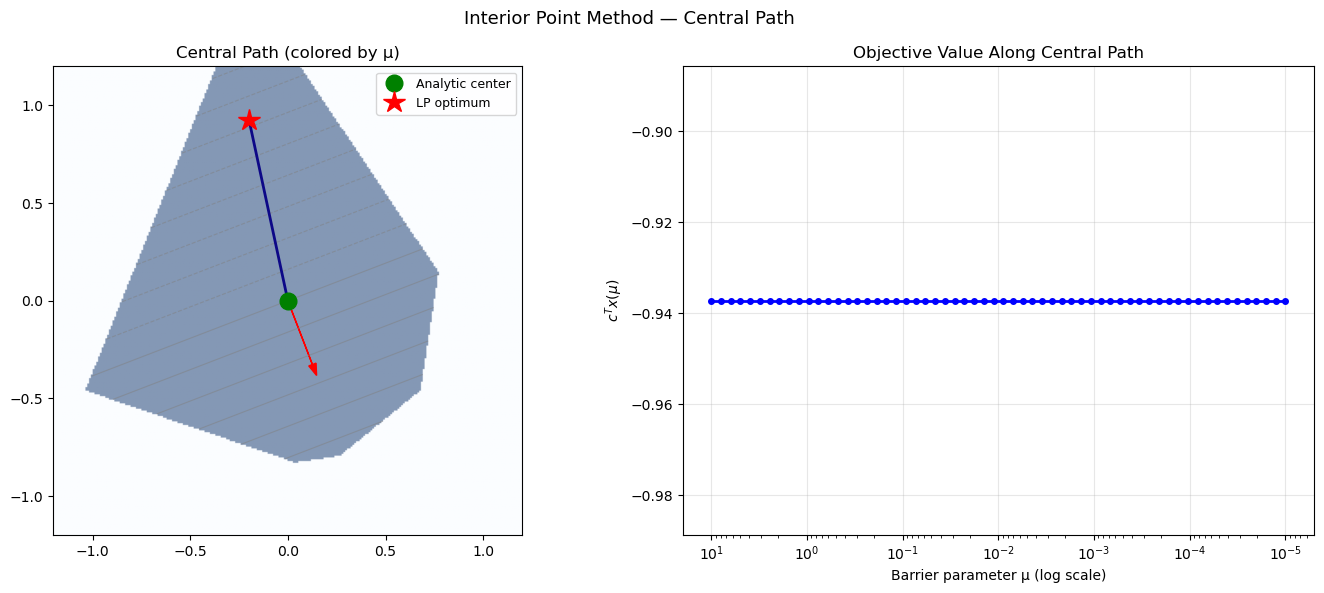

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax = axes[0]
ax.imshow(feasible_mask.T.astype(float), extent=[-1.2,1.2,-1.2,1.2],
          origin='lower', cmap='Blues', alpha=0.5)
f_masked2 = np.where(feasible_mask, f_obj, np.nan)
ax.contour(Xg, Yg, f_masked2, levels=15, colors='gray', linewidths=0.8, alpha=0.5)

# Color the central path by mu value
n_path = len(central_path)
path_colors = plt.cm.plasma(np.linspace(0, 1, n_path))
for i in range(n_path - 1):
    ax.plot(central_path[i:i+2, 0], central_path[i:i+2, 1],
            '-', color=path_colors[i], lw=2)
ax.plot(*central_path[0], 'go', ms=12, label='Analytic center')
ax.plot(*central_path[-1], 'r*', ms=16, label='LP optimum')
ax.arrow(0, 0, 0.35*c_obj[0], 0.35*c_obj[1],
         head_width=0.04, fc='red', ec='red')
ax.set_xlim(-1.2, 1.2); ax.set_ylim(-1.2, 1.2)
ax.set_aspect('equal'); ax.legend(fontsize=9)
ax.set_title('Central Path (colored by μ)', fontsize=12)

# Objective value along the path
axes[1].semilogx(mu_list, (central_path[1:]) @ c_obj, 'b-o', ms=4, lw=2)
axes[1].set_xlabel('Barrier parameter μ (log scale)')
axes[1].set_ylabel('$c^T x(\\mu)$')
axes[1].set_title('Objective Value Along Central Path')
axes[1].invert_xaxis(); axes[1].grid(True, alpha=0.3)

plt.suptitle('Interior Point Method — Central Path', fontsize=13)
plt.tight_layout(); plt.savefig('ip_central_path.png', dpi=100, bbox_inches='tight'); plt.show()

### Barrier function level sets

We visualize the log-barrier objective $\phi_\mu(x)$ for several values of $\mu$. As $\mu$ decreases, the level sets of $\phi_\mu$ deform from ellipses (near the center) to elongated shapes pointing toward the optimal vertex.

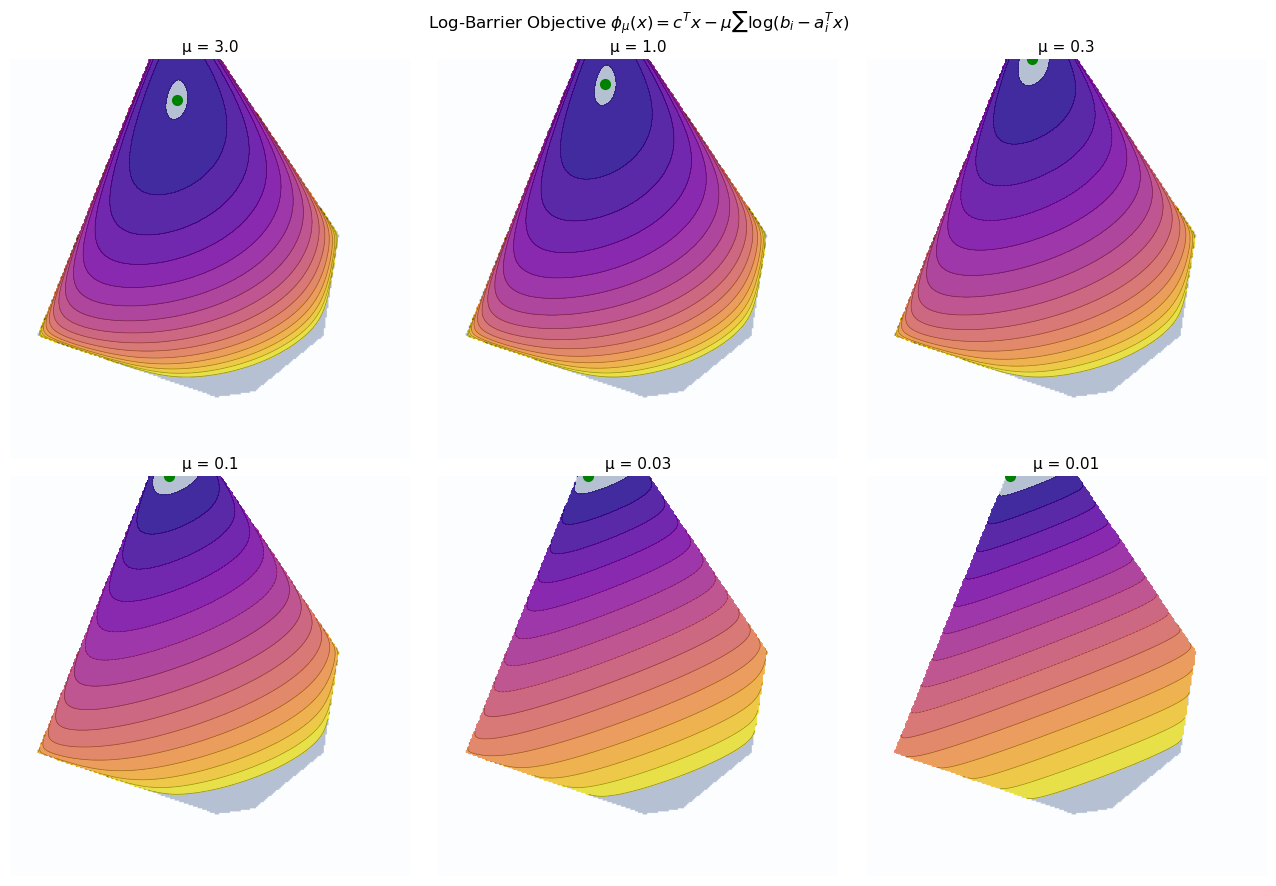

In [5]:
mu_show = [3.0, 1.0, 0.3, 0.1, 0.03, 0.01]
fig, axes = plt.subplots(2, 3, figsize=(13, 9))

for ax, mu in zip(axes.ravel(), mu_show):
    # Compute barrier objective on grid
    phi = np.full(g*g, np.nan)
    for k, pt in enumerate(pts_grid):
        slacks = b - A @ pt
        if np.all(slacks > 0):
            phi[k] = c_obj @ pt - mu * np.sum(np.log(slacks))
    phi_grid = phi.reshape(g, g)

    # Find minimizer at this mu
    x_mu_idx = np.nanargmin(phi)
    x_mu = pts_grid[x_mu_idx]

    finite_vals = phi[np.isfinite(phi)]
    v_low = np.percentile(finite_vals, 1)
    v_high = np.percentile(finite_vals, 95)

    ax.imshow(feasible_mask.T.astype(float), extent=[-1.2,1.2,-1.2,1.2],
              origin='lower', cmap='Blues', alpha=0.3)
    ax.contourf(Xg, Yg, phi_grid, levels=np.linspace(v_low, v_high, 15),
                cmap='plasma', alpha=0.8)
    ax.contour(Xg, Yg, phi_grid, levels=np.linspace(v_low, v_high, 15),
               colors='k', linewidths=0.5, alpha=0.4)
    ax.plot(*x_mu, 'g.', ms=14)
    ax.set_title(f'μ = {mu}', fontsize=11)
    ax.set_aspect('equal'); ax.set_xlim(-1.2, 1.2); ax.set_ylim(-1.2, 1.2)
    ax.axis('off')

plt.suptitle('Log-Barrier Objective $\\phi_\\mu(x) = c^Tx - \\mu \\sum \\log(b_i - a_i^Tx)$', fontsize=12)
plt.tight_layout(); plt.savefig('ip_barriers.png', dpi=100, bbox_inches='tight'); plt.show()

### Interactive: vary the objective direction

### Snippet

In [6]:
STATIC_SNAPSHOT = True
if STATIC_SNAPSHOT:
    import matplotlib
    matplotlib.use('Agg')
    import matplotlib.pyplot as _plt

    fig, axes = _plt.subplots(2, 3, figsize=(12, 8))
    for ax, mu in zip(axes.ravel(), mu_show):
        phi_s = np.full(g*g, np.nan)
        for k, pt in enumerate(pts_grid):
            slacks = b - A @ pt
            if np.all(slacks > 0):
                phi_s[k] = c_obj @ pt - mu * np.sum(np.log(slacks))
        phi_gs = phi_s.reshape(g, g)
        fin = phi_s[np.isfinite(phi_s)]
        if len(fin) == 0: continue
        vl, vh = np.percentile(fin, 2), np.percentile(fin, 60)
        ax.imshow(feasible_mask.T.astype(float), extent=[-1.2,1.2,-1.2,1.2],
                  origin='lower', cmap='Blues', alpha=0.3)
        ax.contourf(Xg, Yg, phi_gs, levels=np.linspace(vl, vh, 12), cmap='plasma', alpha=0.85)
        x_mu_idx = np.nanargmin(phi_s)
        ax.plot(*pts_grid[x_mu_idx], 'g.', ms=12)
        ax.set_title(f'μ={mu}', fontsize=10)
        ax.set_aspect('equal'); ax.set_xlim(-1.2,1.2); ax.set_ylim(-1.2,1.2); ax.axis('off')
    fig.tight_layout()
    fig.savefig('snippet.png', dpi=150, bbox_inches='tight')

## Takeaways

- The log-barrier method converts the LP to a smooth unconstrained problem by penalizing constraint violations.
- As $\mu \to 0$, the minimizer follows the **central path** from the analytic center to the optimal LP vertex.
- Interior point methods have polynomial worst-case complexity — a major theoretical advantage over the simplex.
- In practice, both simplex and interior-point are competitive; IPMs excel for large dense problems.

## Bibliography

- N. Karmarkar, *A new polynomial-time algorithm for linear programming*, Combinatorica 4, 1984.
- S. Boyd & L. Vandenberghe, *Convex Optimization*, Cambridge UP, 2004 (Chapter 11).
- Y. Nesterov & A. Nemirovskii, *Interior-Point Polynomial Algorithms in Convex Programming*, SIAM, 1994.